In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Math dataset
data_path = '../data/student-mat.csv'
df = pd.read_csv(data_path, sep=';')

print("Dataset successfully loaded!")
print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")
df.head()

Dataset successfully loaded!
Total Rows: 395, Total Columns: 33


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
# Check data types, null values, and basic summary statistics
print("--- Missing Values Check ---")
print(df.isnull().sum().max())  # Confirms no missing entries across all columns

print("\n--- Target Variable (G3) Summary ---")
print(df['G3'].describe())

--- Missing Values Check ---
0

--- Target Variable (G3) Summary ---
count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64


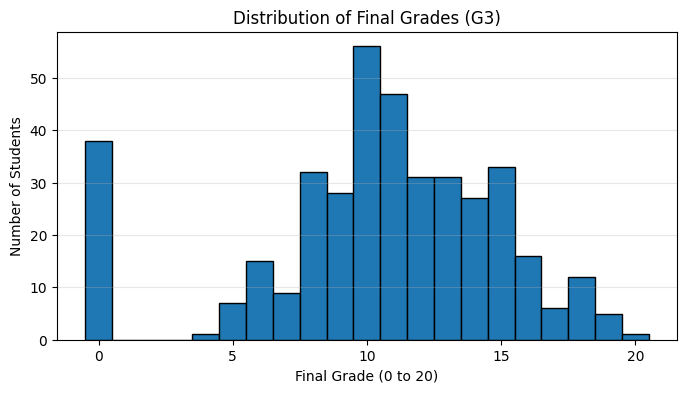

In [5]:
plt.figure(figsize=(8, 4))
plt.hist(df['G3'], bins=21, range=(-0.5, 20.5), edgecolor='black', color='#1f77b4')
plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Final Grade (0 to 20)")
plt.ylabel("Number of Students")
plt.grid(axis='y', alpha=0.3)
plt.show()

In [6]:
# Select numeric columns and check correlation with G3
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['G3'].sort_values(ascending=False)

print("Correlation with G3:")
print(correlations)

Correlation with G3:
G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64


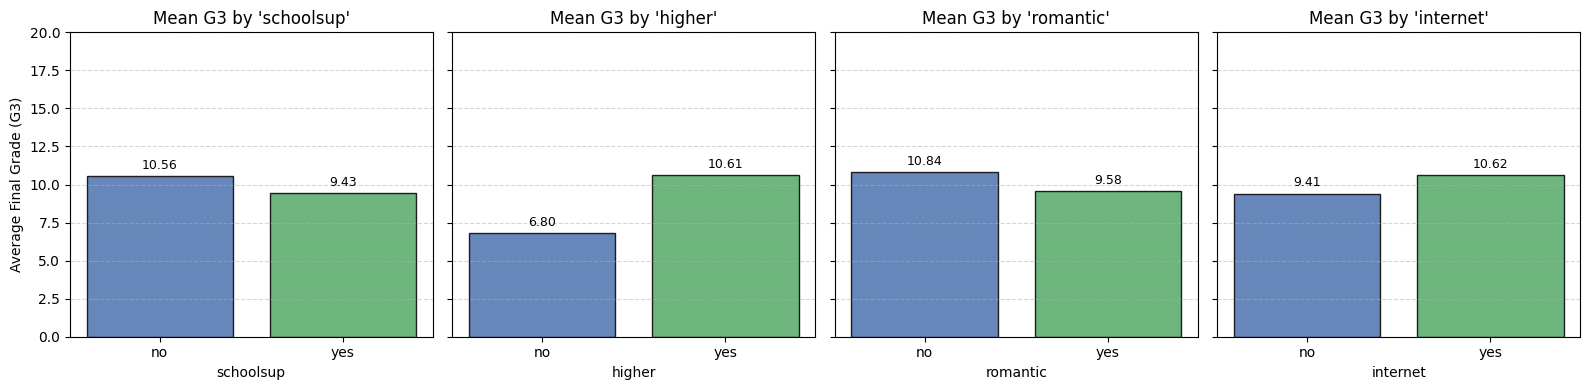

Plot saved to ../images/categorical_impact_on_g3.png


In [7]:
import os

# Ensure images directory exists
os.makedirs('../images', exist_ok=True)

# Compare G3 across key binary/categorical variables
categorical_cols = ['schoolsup', 'higher', 'romantic', 'internet']

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for ax, col in zip(axes, categorical_cols):
    grouped = df.groupby(col)['G3'].mean()
    counts = df[col].value_counts()
    
    bars = ax.bar(grouped.index, grouped.values, color=['#4C72B0', '#55A868'], edgecolor='black', alpha=0.85)
    ax.set_title(f"Mean G3 by '{col}'")
    ax.set_xlabel(col)
    ax.set_ylim(0, 20)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Annotate mean value on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

axes[0].set_ylabel("Average Final Grade (G3)")
plt.tight_layout()
plt.savefig('../images/categorical_impact_on_g3.png', dpi=300)
plt.show()

print("Plot saved to ../images/categorical_impact_on_g3.png")

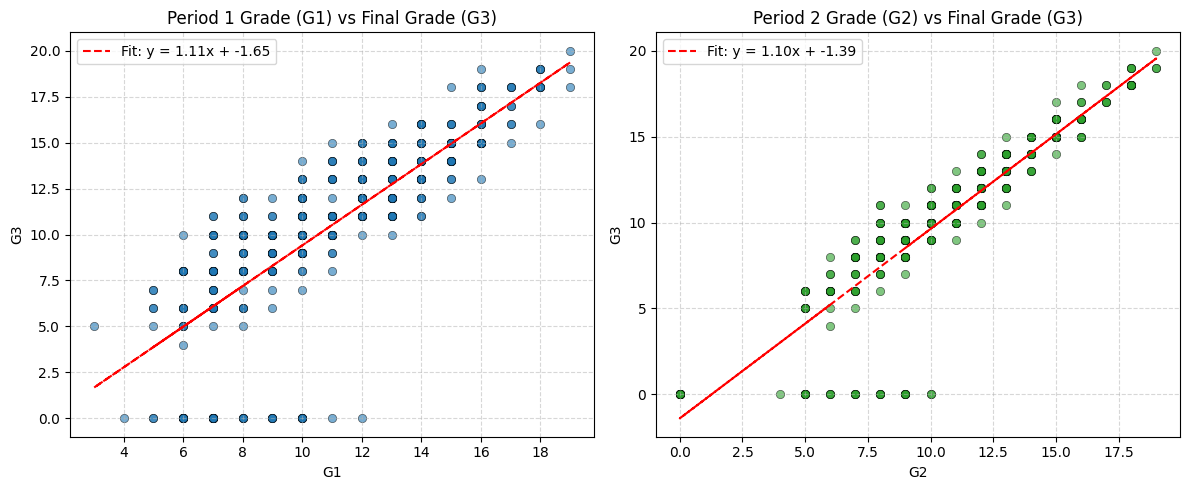

Trend plots saved to ../images/g1_g2_vs_g3_trends.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# G1 vs G3
axes[0].scatter(df['G1'], df['G3'], alpha=0.6, color='#1f77b4', edgecolors='k', linewidth=0.5)
m1, b1 = np.polyfit(df['G1'], df['G3'], 1)
axes[0].plot(df['G1'], m1*df['G1'] + b1, color='red', linestyle='--', label=f'Fit: y = {m1:.2f}x + {b1:.2f}')
axes[0].set_title("Period 1 Grade (G1) vs Final Grade (G3)")
axes[0].set_xlabel("G1")
axes[0].set_ylabel("G3")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# G2 vs G3
axes[1].scatter(df['G2'], df['G3'], alpha=0.6, color='#2ca02c', edgecolors='k', linewidth=0.5)
m2, b2 = np.polyfit(df['G2'], df['G3'], 1)
axes[1].plot(df['G2'], m2*df['G2'] + b2, color='red', linestyle='--', label=f'Fit: y = {m2:.2f}x + {b2:.2f}')
axes[1].set_title("Period 2 Grade (G2) vs Final Grade (G3)")
axes[1].set_xlabel("G2")
axes[1].set_ylabel("G3")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../images/g1_g2_vs_g3_trends.png', dpi=300)
plt.show()

print("Trend plots saved to ../images/g1_g2_vs_g3_trends.png")

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Separate features (X) and target (y)
X = df.drop(columns=['G3'])
y = df['G3']

# 2. Identify categorical and numeric feature columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# 3. Construct preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

# 4. Stratified/Random train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# 5. Define candidate models
models = {
    "Linear Regression (OLS)": LinearRegression(),
    "Ridge Regression (L2)": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

# 6. Fit and evaluate each model
results = []
for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    # Calculate performance metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "RMSE": round(rmse, 3),
        "MAE": round(mae, 3),
        "R^2 Score": round(r2, 3)
    })

results_df = pd.DataFrame(results)
print("--- Baseline Model Performance Comparison ---")
results_df

/Users/jaskirat_singh_grewal/Documents/IDC409_Project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/jaskirat_singh_grewal/Documents/IDC409_Project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/jaskirat_singh_grewal/Documents/IDC409_Project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/jaskirat_singh_grewal/Documents/IDC409_Project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jaskirat_singh_grewal/Documents/IDC409_Project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Use

--- Baseline Model Performance Comparison ---


,Model,RMSE,MAE,R^2 Score
0,Linear Regression (OLS),2.378,1.647,0.724
1,Ridge Regression (L2),2.368,1.635,0.726
2,Random Forest,1.958,1.179,0.813


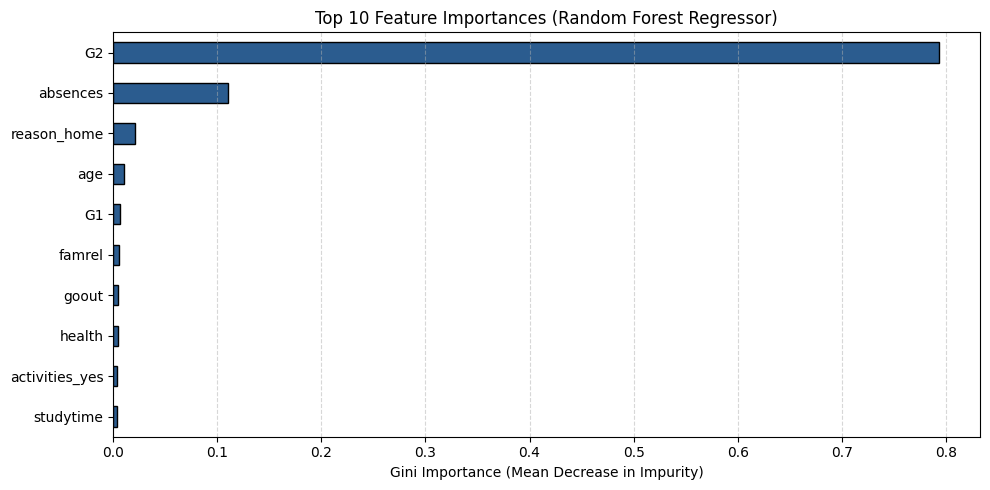

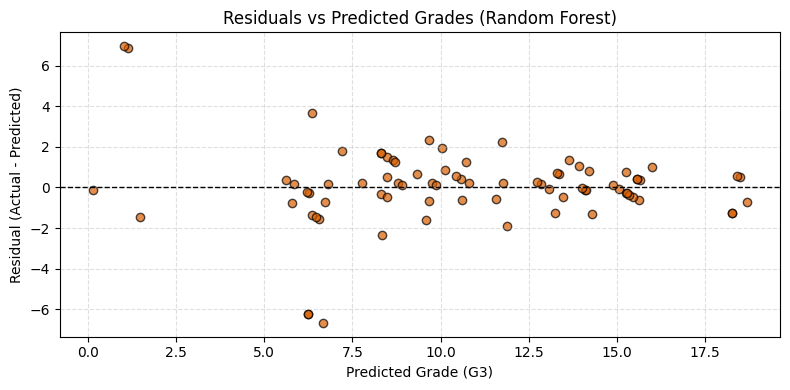

Top 5 features driving the predictions:
G2             0.793254
absences       0.110093
reason_home    0.021086
age            0.010433
G1             0.005979
dtype: float64


In [11]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Fit the optimal Random Forest model to extract feature importances
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])
rf_pipeline.fit(X_train, y_train)

# Extract transformed feature names
cat_encoder = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features).tolist()
all_features = numeric_features + cat_feature_names

# Get feature importances from Random Forest
importances = rf_pipeline.named_steps['regressor'].feature_importances_
importance_series = pd.Series(importances, index=all_features).sort_values(ascending=False)

# Plot top 10 most predictive features
plt.figure(figsize=(10, 5))
importance_series.head(10).plot(kind='barh', color='#2b5c8f', edgecolor='black')
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (Random Forest Regressor)")
plt.xlabel("Gini Importance (Mean Decrease in Impurity)")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../images/feature_importances.png', dpi=300)
plt.show()

# Compute predictions and residuals
y_pred_rf = rf_pipeline.predict(X_test)
residuals = y_test - y_pred_rf

# Residual Plot
plt.figure(figsize=(8, 4))
plt.scatter(y_pred_rf, residuals, color='#d95f02', edgecolor='black', alpha=0.7)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title("Residuals vs Predicted Grades (Random Forest)")
plt.xlabel("Predicted Grade (G3)")
plt.ylabel("Residual (Actual - Predicted)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../images/rf_residuals.png', dpi=300)
plt.show()

print("Top 5 features driving the predictions:")
print(importance_series.head(5))